In [39]:
import pandas as pd
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model

def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

set_seed(42)
results={}
scale=StandardScaler()

In [40]:
#import dataframe
df_modelling=pd.read_parquet("../df_modelling.parquet")

Without Rolling Window:

In [41]:
#creating market vector
# 'Stock_Date', 'Closing Price($)', 'relative difference',
#        'comment_published_at_median_YMD', 'number_of_comments_at_date',
#        'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
#        'sentiment_tensor', 'videos_text_embeddings', 'TargetVariable:Up/Down'
numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days'],
      dtype='object')


In [42]:
#function for creating sequences
def create_sequences(embeddings, numeric, target, sequence_length):
    X_emb_seq = []
    X_num_seq = []
    y_seq = []

    for i in range(sequence_length, len(embeddings)):
        X_emb_seq.append(embeddings[i-sequence_length:i])
        X_num_seq.append(numeric[i-sequence_length:i])
        y_seq.append(target[i])

    return (
        np.array(X_emb_seq),
        np.array(X_num_seq),
        np.array(y_seq)
    )

In [43]:
# embeddings_array=np.stack(df_modelling['embeddings_vector'])
# Embeddings_reduced=embeddings_array 
# numerical_values=np.stack(df_modelling[numerical_columns].values)
# y = df_modelling['TargetVariable:Up/Down'].values

sequence_length = 20  # timesteps
# emb_features = 512    # embedding dimension

# # X_emb_flat shape = (total_rows, 256)
# # X_fin_flat shape = (total_rows, 16)
# # y_flat shape = (total_rows, 1)

# X_emb_seq = []
# X_fin_seq = []
# y_seq = []

# for i in range(len(Embeddings_reduced) - sequence_length):
#     X_emb_seq.append(Embeddings_reduced[i:i+sequence_length])
#     X_fin_seq.append(numerical_values[i:i+sequence_length])  # financial features of last timestep
#     y_seq.append(y[i+sequence_length-1])

# X_emb_seq = np.array(X_emb_seq)         # shape = (num_samples, 450, 256)
# X_fin_seq = np.array(X_fin_seq) # shape = (num_samples, 16)
# y_seq = np.array(y_seq)         # shape = (num_samples, 1)

#splitting data
embeddings_array = np.stack(df_modelling['embeddings_vector'])
numerical_values = np.stack(df_modelling[numerical_columns].values)
y = df_modelling['TargetVariable:Up/Down'].values


N = len(embeddings_array)
#train 70% val 20% test 10%
train_end = int(N * 0.7)
val_end = int(N * 0.9)

# Raw splits
emb_train_raw = embeddings_array[:train_end]
emb_val_raw = embeddings_array[train_end:val_end]
emb_test_raw = embeddings_array[val_end:]

num_train_raw = numerical_values[:train_end]
num_val_raw = numerical_values[train_end:val_end]
num_test_raw = numerical_values[val_end:]

y_train_raw = y[:train_end]
y_val_raw = y[train_end:val_end]
y_test_raw = y[val_end:]

num_train_raw = scale.fit_transform(num_train_raw)
num_val_raw = scale.transform(num_val_raw)
num_test_raw = scale.transform(num_test_raw)


In [44]:

#LSTM will look 20 steps in the past
X_emb_train, X_num_train, y_train = create_sequences(emb_train_raw, num_train_raw, y_train_raw, sequence_length)
X_emb_val, X_num_val, y_val = create_sequences(emb_val_raw, num_val_raw, y_val_raw, sequence_length)
X_emb_test, X_num_test, y_test = create_sequences(emb_test_raw, num_test_raw, y_test_raw, sequence_length)

In [45]:

# Inputs
embedding_input = Input(shape=(sequence_length,X_emb_train.shape[2]))   # change 50 to your seq_len
numeric_input = Input(shape=(sequence_length,X_num_train.shape[2]))

# Embeddings branch
x = LSTM(64, return_sequences=True)(embedding_input)
x = LSTM(32)(x)

#numerical branch
z= LSTM(16, return_sequences=True)(numeric_input)
z= LSTM(8)(z)

# Concatenate numeric features
x = Concatenate()([x, z])

# Output
output = Dense(1, activation='sigmoid')(x)

# Build model
model = Model(inputs=[embedding_input, numeric_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 20, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 20, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 20, 64)    │    147,712 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ (None, 20, 16)    │      1,472 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 32)        │     12,416 │ lstm_8[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ (None, 8)         │        800 │ lstm_10[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 40)        │          0 │ lstm_9[0][0],     │
│ (Concatenate)       │                   │            │ lstm_11[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         41 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 162,441 (634.54 KB)

 Trainable params: 162,441 (634.54 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# #splitting
# def get_train_test_chrono_split(X):
# #creating the splits for train & test
#     split_at=int(X.shape[0]*0.7)
#     _train=X[:split_at]
#     _val=X[split_at:int(X.shape[0]*0.9)]
#     _test=X[int(X.shape[0]*0.9):]
#     return _train, _val, _test
# #splitting into train, val and test
# X_emb_train, X_emb_val, X_emb_test=get_train_test_chrono_split(X_emb_seq)
# X_num_train, X_num_val, X_num_test=get_train_test_chrono_split(X_fin_seq)
# y_train, y_val, y_test=get_train_test_chrono_split(y_seq)





# print(X_emb_train.shape)

In [47]:
history = model.fit(
    [X_emb_train, X_num_train],  # inputs
    y_train,                        # labels
    validation_data=([X_emb_val, X_num_val], y_val),
    epochs=200,                      # start with 10, can increase
    batch_size=32,                  # tune depending on memory
    shuffle=False
)


Epoch 1/200


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_16', 'keras_tensor_17']. Received: the structure of inputs=('*', '*')
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - accuracy: 0.4335 - loss: 0.7039 - val_accuracy: 0.5513 - val_loss: 0.6871
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4557 - loss: 0.6962 - val_accuracy: 0.5513 - val_loss: 0.6918
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4903 - loss: 0.6954 - val_accuracy: 0.4615 - val_loss: 0.6945
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4903 - loss: 0.6930 - val_accuracy: 0.5128 - val_loss: 0.6938
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5283 - loss: 0.6891 - val_accuracy: 0.5128 - val_loss: 0.6919
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5735 - loss: 0.6844 - val_accuracy: 0.5385 - val_loss: 0.6904
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5743 - loss: 0.6779 - val_accuracy: 0.5385 - val_loss: 0.6867
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5878 - loss: 0.6663 - val_accuracy: 0.4615 - val_

In [48]:
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0

#selecting best threshold on val data

y_prob = model.predict([X_emb_val, X_num_val])
for threshold in thresholds:
    y_pred_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_pred_tr, output_dict=True)
    f1_scores.append(report['macro avg']['f1-score'])

#deciding the best index    
f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#now deciding F1 on test data with the decided best threshold
y_prob = model.predict([X_emb_test, X_num_test])
y_pred_tr = (y_prob > threshold).astype(int)
report=classification_report(y_test, y_pred_tr, output_dict=True)
f1=report['macro avg']['f1-score']
print(f"Best Result is f1 {f1} at threshold {threshold}")
results["without Window"]=[f1, threshold, report]

1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x159467060> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Best Result is f1 0.4827586206896552 at threshold 0.4


/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
              precision    recall  f1-score   support

           0       0.44      0.54      0.48        13
           1       0.54      0.44      0.48        16

    accuracy                           0.48        29
   macro avg       0.49      0.49      0.48        29
weighted avg       0.49      0.48      0.48        29

confusion_matrix is:


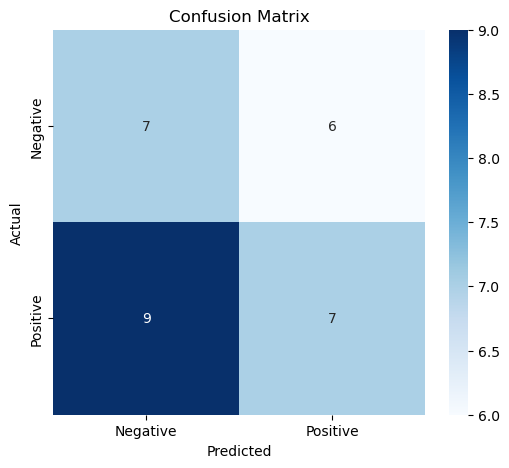

In [49]:
y_prob = model.predict([X_emb_test, X_num_test])
y_pred = (y_prob > threshold).astype(int)
print(classification_report(y_test, y_pred))

print("confusion_matrix is:")
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

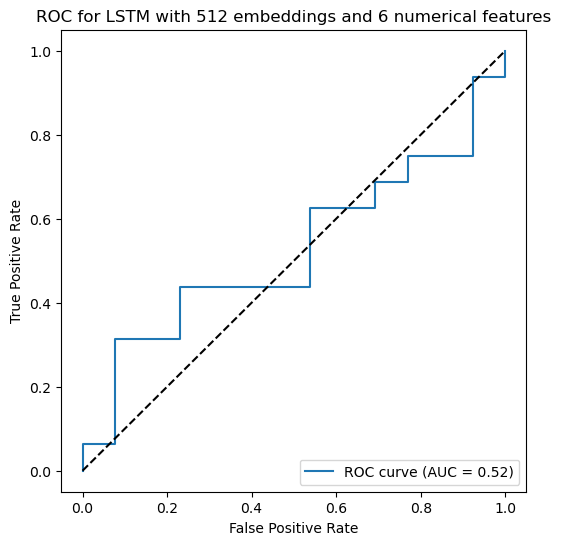

In [50]:
auc=roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.title("ROC for LSTM with 512 embeddings and 6 numerical features")
plt.show()

With Rolling Window

In [51]:

numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings_window'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days', 'embeddings_vector'],
      dtype='object')


In [52]:
#function for creating sequences
def create_sequences(embeddings, numeric, target, sequence_length):
    X_emb_seq = []
    X_num_seq = []
    y_seq = []

    for i in range(sequence_length, len(embeddings)):
        X_emb_seq.append(embeddings[i-sequence_length:i])
        X_num_seq.append(numeric[i-sequence_length:i])
        y_seq.append(target[i])

    return (
        np.array(X_emb_seq),
        np.array(X_num_seq),
        np.array(y_seq)
    )

In [53]:


sequence_length = 20  # timesteps


#splitting data
embeddings_array = np.stack(df_modelling['embeddings_vector'])
numerical_values = np.stack(df_modelling[numerical_columns].values)
y = df_modelling['TargetVariable:Up/Down'].values


N = len(embeddings_array)
#train 70% val 20% test 10%
train_end = int(N * 0.7)
val_end = int(N * 0.9)

# Raw splits
emb_train_raw = embeddings_array[:train_end]
emb_val_raw = embeddings_array[train_end:val_end]
emb_test_raw = embeddings_array[val_end:]

num_train_raw = numerical_values[:train_end]
num_val_raw = numerical_values[train_end:val_end]
num_test_raw = numerical_values[val_end:]

y_train_raw = y[:train_end]
y_val_raw = y[train_end:val_end]
y_test_raw = y[val_end:]

num_train_raw = scale.fit_transform(num_train_raw)
num_val_raw = scale.transform(num_val_raw)
num_test_raw = scale.transform(num_test_raw)


In [54]:

#LSTM will look 20 steps in the past
X_emb_train, X_num_train, y_train = create_sequences(emb_train_raw, num_train_raw, y_train_raw, sequence_length)
X_emb_val, X_num_val, y_val = create_sequences(emb_val_raw, num_val_raw, y_val_raw, sequence_length)
X_emb_test, X_num_test, y_test = create_sequences(emb_test_raw, num_test_raw, y_test_raw, sequence_length)

In [55]:
# Inputs
embedding_input = Input(shape=(sequence_length,X_emb_train.shape[2]))   # change 50 to your seq_len
numeric_input = Input(shape=(sequence_length,X_num_train.shape[2]))

# Embeddings branch
x = LSTM(64, return_sequences=True)(embedding_input)
x = LSTM(32)(x)

#numerical branch
z= LSTM(16, return_sequences=True)(numeric_input)
z= LSTM(8)(z)

# Concatenate numeric features
x = Concatenate()([x, z])

# Output
output = Dense(1, activation='sigmoid')(x)

# Build model
model = Model(inputs=[embedding_input, numeric_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 20, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 20, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_12 (LSTM)      │ (None, 20, 64)    │    147,712 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_14 (LSTM)      │ (None, 20, 16)    │      1,472 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_13 (LSTM)      │ (None, 32)        │     12,416 │ lstm_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_15 (LSTM)      │ (None, 8)         │        800 │ lstm_14[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 40)        │          0 │ lstm_13[0][0],    │
│ (Concatenate)       │                   │            │ lstm_15[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         41 │ concatenate_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 162,441 (634.54 KB)

 Trainable params: 162,441 (634.54 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# #splitting
# def get_train_test_chrono_split(X):
# #creating the splits for train & test
#     split_at=int(X.shape[0]*0.7)
#     _train=X[:split_at]
#     _val=X[split_at:int(X.shape[0]*0.9)]
#     _test=X[int(X.shape[0]*0.9):]
#     return _train, _val, _test
# #splitting into train, val and test
# X_emb_train, X_emb_val, X_emb_test=get_train_test_chrono_split(X_emb_seq)
# X_num_train, X_num_val, X_num_test=get_train_test_chrono_split(X_fin_seq)
# y_train, y_val, y_test=get_train_test_chrono_split(y_seq)





# print(X_emb_train.shape)

In [57]:
history = model.fit(
    [X_emb_train, X_num_train],  # inputs
    y_train,                        # labels
    validation_data=([X_emb_val, X_num_val], y_val),
    epochs=200,                      # start with 10, can increase
    batch_size=32,                  # tune depending on memory
    shuffle=False
)

model.save("best_model_LSTM.keras")

Epoch 1/200


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_24', 'keras_tensor_25']. Received: the structure of inputs=('*', '*')
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.4734 - loss: 0.6939 - val_accuracy: 0.4872 - val_loss: 0.6951
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5632 - loss: 0.6897 - val_accuracy: 0.4231 - val_loss: 0.6992
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5329 - loss: 0.6888 - val_accuracy: 0.4231 - val_loss: 0.7000
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5682 - loss: 0.6863 - val_accuracy: 0.4872 - val_loss: 0.6989
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5606 - loss: 0.6825 - val_accuracy: 0.5128 - val_loss: 0.6988
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5544 - loss: 0.6762 - val_accuracy: 0.4231 - val_loss: 0.7030
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5597 - loss: 0.6619 - val_accuracy: 0.4872 - val_loss: 0.7337
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5970 - loss: 0.6633 - val_accuracy: 0.5128 - val_

In [58]:
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0

#selecting best threshold on val data

y_prob = model.predict([X_emb_val, X_num_val])
for threshold in thresholds:
    y_pred_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_pred_tr, output_dict=True)
    f1_scores.append(report['macro avg']['f1-score'])

#deciding the best index    
f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#now deciding F1 on test data with the decided best threshold
y_prob = model.predict([X_emb_test, X_num_test])
y_pred_tr = (y_prob > threshold).astype(int)
report=classification_report(y_test, y_pred_tr, output_dict=True)
f1=report['macro avg']['f1-score']
print(f"Best Result is f1 {f1} at threshold {threshold}")
results["with Window"]=[f1, threshold, report]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Best Result is f1 0.6133333333333333 at threshold 0.7000000000000001


/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
              precision    recall  f1-score   support

           0       0.55      0.85      0.67        13
           1       0.78      0.44      0.56        16

    accuracy                           0.62        29
   macro avg       0.66      0.64      0.61        29
weighted avg       0.68      0.62      0.61        29

confusion_matrix is:


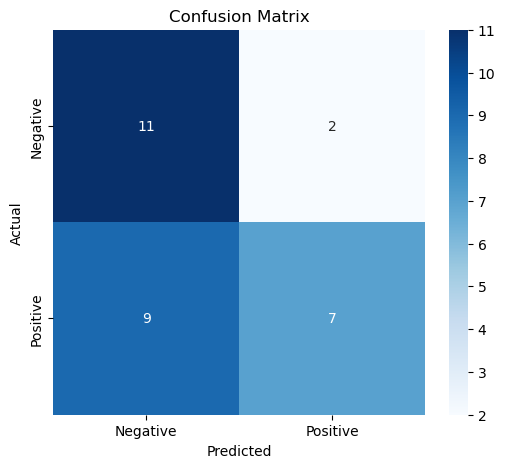

In [59]:
y_prob = model.predict([X_emb_test, X_num_test])
y_pred = (y_prob > threshold).astype(int)
print(classification_report(y_test, y_pred))

print("confusion_matrix is:")
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

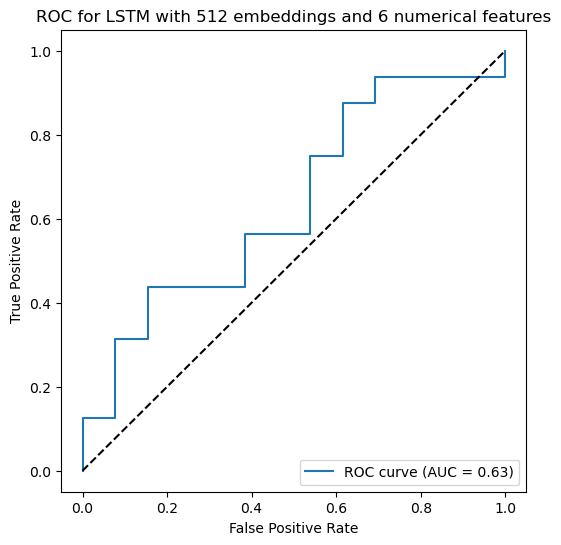

In [60]:
auc=roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.title("ROC for LSTM with 512 embeddings and 6 numerical features")
plt.show()

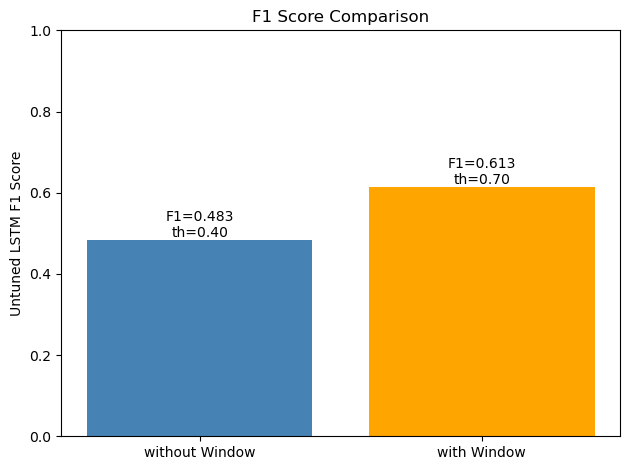

In [61]:
labels = list(results.keys())

f1_scores = [v[0] for v in results.values()]
thresholds = [v[1] for v in results.values()]

bars = plt.bar(labels, f1_scores, color=["steelblue", "orange"])

plt.ylabel("Untuned LSTM F1 Score")
plt.title("F1 Score Comparison")
plt.ylim(0, 1)

# Add F1 + threshold as text
for bar, f1, th in zip(bars, f1_scores, thresholds):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"F1={f1:.3f}\nth={th:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Conclusion: LSTM works better with rolling window
